In [46]:
import matplotlib.pyplot as plt
import anndata as ad
import glob
import os
import gc
import numpy as np
import pandas as pd
import pylab as py # qq-plot
import pingouin as pg
import scanpy as sc
from scipy import stats
import scipy.sparse as sp
import seaborn as sns
import statsmodels.api as sm # qq-plot
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

from collections import defaultdict
from pathlib import Path

from analysis_lincs import load_test_results, control_baseline_metrics, mean_baseline_metrics, technical_duplicate_metrics, prnet_evaluation_metrics
from scipy.stats import wilcoxon, ttest_rel
from sklearn.metrics import mean_squared_error # (Methods used come from validation in prnet trainer)
from models.simple_baselines import control_baseline, mean_baseline, technical_duplicate_baseline

In [47]:
expression_data_dir = Path("/home/ani/Documents/uni/prnet_eval/results/batch_run_00/intermediates/preprocessed_dataset.h5ad")
expression_data_dir2 = Path("/home/ani/Documents/uni/prnet_eval/results/batch_run_01/intermediates/updated_dataset.h5ad")

results_data_dir = Path("/home/ani/Documents/uni/prnet_eval/results/batch_run_00/evaluation")
results_data_dir2 = Path("/home/ani/Documents/uni/prnet_eval/results/batch_run_01/evaluation")


adata = sc.read_h5ad(expression_data_dir)
adata2 = sc.read_h5ad(expression_data_dir2) 

In [48]:
prnet_metrics_smiles_path = Path(results_data_dir / "prnet_metrics_smiles.parquet")
prnet_metrics_fp_path = Path(results_data_dir / "prnet_metrics_fp.parquet")
prnet_metrics_map4c_path = Path(results_data_dir2 / "prnet_metrics_map4c.parquet")


In [49]:
if prnet_metrics_smiles_path.exists():
    smiles_metrics = pd.read_parquet(prnet_metrics_smiles_path)     

In [50]:
if prnet_metrics_fp_path.exists():
    embedding_metrics = pd.read_parquet(prnet_metrics_fp_path)

In [51]:
if prnet_metrics_map4c_path.exists():
    map4c_metrics = pd.read_parquet(prnet_metrics_map4c_path)

In [52]:
models = {
    "PRnet [SMILES]": smiles_metrics,
    "PRnet [Embedding]": embedding_metrics
}

data_split_metrics_df = (
    pd.concat(models.values(), keys=models.keys(), names=["model", None])
    .reset_index(level="model")
    .reset_index(drop=True)
)

if "Unnamed: 0" in data_split_metrics_df.columns:
    data_split_metrics_df = data_split_metrics_df.rename(columns={"Unnamed: 0": "epoch"})

data_split_metrics_df

,model,fold,cov_drug,Pearson,Pearson Delta,MSE
0,PRnet [SMILES],canonical_smiles_split_0,HEPG2_BRD-K60230970,0.407667,0.967526,0.185378
1,PRnet [SMILES],canonical_smiles_split_0,PC3_BRD-K60230970,0.344459,0.976010,0.129686
2,PRnet [SMILES],canonical_smiles_split_0,MCF10A_BRD-K35629949,0.673403,0.988741,0.058496
3,PRnet [SMILES],canonical_smiles_split_0,PC3_BRD-K42091312,0.452231,0.973060,0.141751
4,PRnet [SMILES],canonical_smiles_split_0,VCAP_BRD-K11746559,0.707414,0.988369,0.065347
...,...,...,...,...,...,...
1456127,PRnet [Embedding],fingerprint_smiles_split_4,VCAP_BRD-K36354764,0.770611,0.994476,0.029183
1456128,PRnet [Embedding],fingerprint_smiles_split_4,VCAP_BRD-K51339020,0.525275,0.987664,0.066152
1456129,PRnet [Embedding],fingerprint_smiles_split_4,HA1E_BRD-K02130563,0.775547,0.994410,0.028791
1456130,PRnet [Embedding],fingerprint_smiles_split_4,HEPG2_BRD-A19037878,0.687726,0.992193,0.041363


In [ ]:
models = {
    "PRnet [Morgan Embedding]": smiles_metrics,
    "PRnet [MAP4C Embedding]": map4c_metrics
}

data_split_metrics_df2 = (
    pd.concat(models.values(), keys=models.keys(), names=["model", None])
    .reset_index(level="model")
    .reset_index(drop=True)
)

if "Unnamed: 0" in data_split_metrics_df2.columns:
    data_split_metrics_df2 = data_split_metrics_df2.rename(columns={"Unnamed: 0": "epoch"})

data_split_metrics_df2

,model,fold,cov_drug,Pearson,Pearson Delta,MSE
0,PRnet [Morgan Embedding],canonical_smiles_split_0,HEPG2_BRD-K60230970,0.407667,0.967526,0.185378
1,PRnet [Morgan Embedding],canonical_smiles_split_0,PC3_BRD-K60230970,0.344459,0.976010,0.129686
2,PRnet [Morgan Embedding],canonical_smiles_split_0,MCF10A_BRD-K35629949,0.673403,0.988741,0.058496
3,PRnet [Morgan Embedding],canonical_smiles_split_0,PC3_BRD-K42091312,0.452231,0.973060,0.141751
4,PRnet [Morgan Embedding],canonical_smiles_split_0,VCAP_BRD-K11746559,0.707414,0.988369,0.065347
...,...,...,...,...,...,...
1456127,PRnet [MAP4C Embedding],canonical_smiles_split_4,PC3_BRD-K90826279,0.681149,0.990406,0.050256
1456128,PRnet [MAP4C Embedding],canonical_smiles_split_4,HCC515_BRD-K07572174,0.712809,0.992190,0.041472
1456129,PRnet [MAP4C Embedding],canonical_smiles_split_4,VCAP_BRD-K17896185,0.682160,0.990576,0.049120
1456130,PRnet [MAP4C Embedding],canonical_smiles_split_4,HUH7_BRD-K35468722,0.693618,0.992650,0.038669


In [ ]:
import numpy as np
import pandas as pd

def paired_cliffs_delta(x, y):
    diffs = x - y
    more = np.sum(diffs > 0)
    less = np.sum(diffs < 0)
    return (more - less) / len(diffs)

def bootstrap_comparison(scores_fp, scores_smiles, n_bootstraps=10000, ci=95):
    diffs = []
    fp_means = []
    smiles_means = []
    n = len(scores_fp)
    
    np.random.seed(42)
    
    for _ in range(n_bootstraps):
        idx = np.random.choice(n, size=n, replace=True)
        
        mean_fp = np.mean(scores_fp[idx])
        mean_smiles = np.mean(scores_smiles[idx])
        
        fp_means.append(mean_fp)
        smiles_means.append(mean_smiles)
        diffs.append(mean_fp - mean_smiles)
        
    alpha = (100 - ci) / 2
    ci_lower = np.percentile(diffs, alpha)
    ci_upper = np.percentile(diffs, 100 - alpha)
    delta = paired_cliffs_delta(scores_fp, scores_smiles)
    
    return {
        'mean_diff': np.mean(scores_fp) - np.mean(scores_smiles),
        f'ci_{ci}_lower': ci_lower,
        f'ci_{ci}_upper': ci_upper,
        'cliffs_delta': delta,
        'bootstrapped_diffs': np.array(diffs), 
        'fp_means': np.array(fp_means),       
        'smiles_means': np.array(smiles_means)
    }

In [100]:
smiles_df = data_split_metrics_df[data_split_metrics_df['model'] == 'PRnet [SMILES]']
fp_df     = data_split_metrics_df[data_split_metrics_df['model'] == 'PRnet [Embedding]']


smiles_agg = smiles_df.groupby("cov_drug")["MSE"].mean()
fp_agg = fp_df.groupby("cov_drug")["MSE"].mean()

aligned = pd.merge(
    fp_agg.rename("fp"),
    smiles_agg.rename("smiles"),
    left_index=True,
    right_index=True,
    how="inner",
)

fp_agg_mse = aligned["fp"].values
smiles_agg_mse = aligned["smiles"].values


In [101]:
results = bootstrap_comparison(
    fp_agg_mse, 
    smiles_agg_mse
)

print(f"Mean Difference (FP - SMILES): {results['mean_diff']:.4f}")
print(f"95% CI: [{results['ci_95_lower']:.4f}, {results['ci_95_upper']:.4f}]")
print(f"Cliff's Delta: {results['cliffs_delta']:.4f}")


Mean Difference (FP - SMILES): -0.0553
95% CI: [-0.0555, -0.0551]
Cliff's Delta: -0.9769


In [ ]:
num_bootstraps=10000

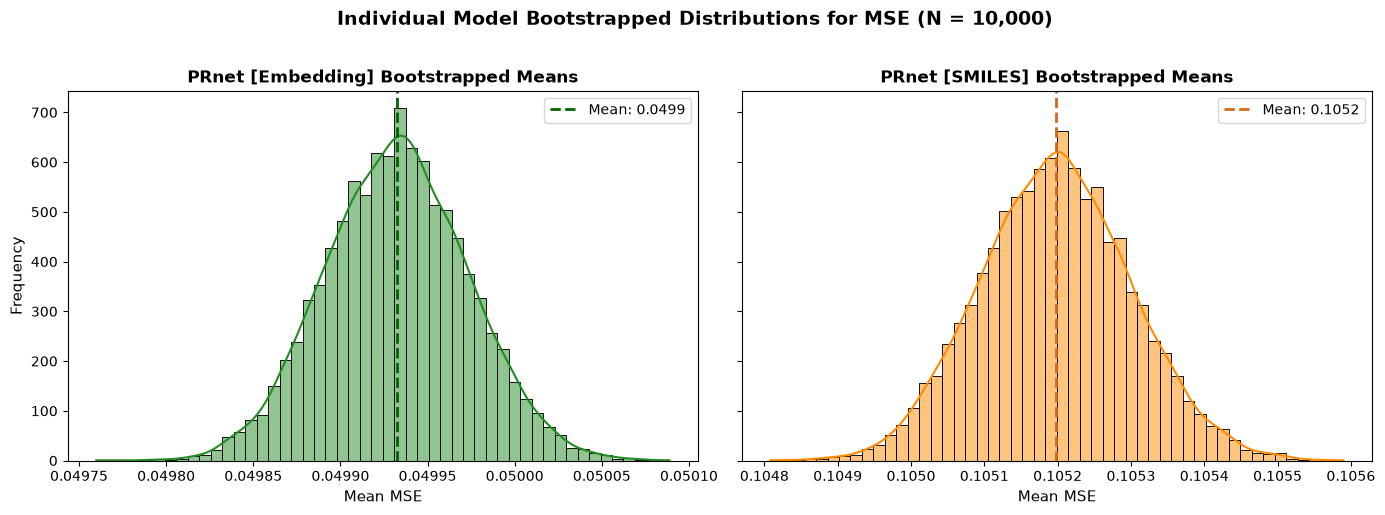

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

sns.histplot(results['fp_means'], kde=True, color='forestgreen', bins=50, ax=axes[0])
mean_fp = results['fp_means'].mean()
axes[0].axvline(mean_fp, color='darkgreen', linestyle='--', linewidth=2, label=f"Mean: {mean_fp:.4f}")
axes[0].set_title("PRnet [Embedding] Bootstrapped Means", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Mean MSE", fontsize=11)
axes[0].set_ylabel("Frequency", fontsize=11)
axes[0].legend()

sns.histplot(results['smiles_means'], kde=True, color='darkorange', bins=50, ax=axes[1])
mean_smiles = results['smiles_means'].mean()
axes[1].axvline(mean_smiles, color='chocolate', linestyle='--', linewidth=2, label=f"Mean: {mean_smiles:.4f}")
axes[1].set_title("PRnet [SMILES] Bootstrapped Means", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Mean MSE", fontsize=11)
axes[1].legend()

plt.suptitle(f"Individual Model Bootstrapped Distributions for MSE (N = {num_bootstraps:,})", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [103]:
smiles_agg = smiles_df.groupby("cov_drug")["Pearson Delta"].mean()
fp_agg = fp_df.groupby("cov_drug")["Pearson Delta"].mean()

aligned = pd.merge(
    fp_agg.rename("fp"),
    smiles_agg.rename("smiles"),
    left_index=True,
    right_index=True,
    how="inner",
)

fp_agg_deltar = aligned["fp"].values
smiles_agg_deltar = aligned["smiles"].values

results2 = bootstrap_comparison(
    fp_agg_deltar, 
    smiles_agg_deltar
)

print(f"Mean Difference (FP - SMILES): {results2['mean_diff']:.4f}")
print(f"95% CI: [{results2['ci_95_lower']:.4f}, {results2['ci_95_upper']:.4f}]")
print(f"Cliff's Delta: {results2['cliffs_delta']:.4f}")

Mean Difference (FP - SMILES): 0.0098
95% CI: [0.0097, 0.0098]
Cliff's Delta: 0.9756


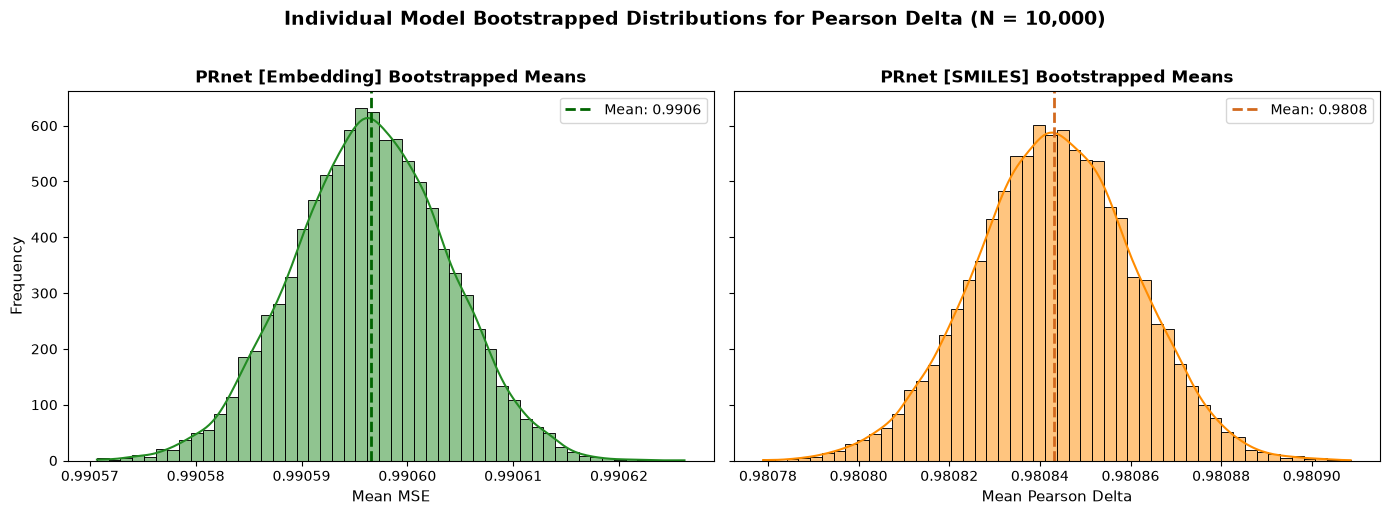

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

sns.histplot(results2['fp_means'], kde=True, color='forestgreen', bins=50, ax=axes[0])
mean_fp = results2['fp_means'].mean()
axes[0].axvline(mean_fp, color='darkgreen', linestyle='--', linewidth=2, label=f"Mean: {mean_fp:.4f}")
axes[0].set_title("PRnet [Embedding] Bootstrapped Means", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Mean MSE", fontsize=11)
axes[0].set_ylabel("Frequency", fontsize=11)
axes[0].legend()

sns.histplot(results2['smiles_means'], kde=True, color='darkorange', bins=50, ax=axes[1])
mean_smiles = results2['smiles_means'].mean()
axes[1].axvline(mean_smiles, color='chocolate', linestyle='--', linewidth=2, label=f"Mean: {mean_smiles:.4f}")
axes[1].set_title("PRnet [SMILES] Bootstrapped Means", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Mean Pearson Delta", fontsize=11)
axes[1].legend()

plt.suptitle(f"Individual Model Bootstrapped Distributions for Pearson Delta (N = {num_bootstraps:,})", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [106]:
smiles_df2 = data_split_metrics_df2[data_split_metrics_df2['model'] == 'PRnet [Morgan Embedding]']
fp_df2     = data_split_metrics_df2[data_split_metrics_df2['model'] == 'PRnet [MAP4C Embedding]']


smiles_agg2 = smiles_df2.groupby("cov_drug")["MSE"].mean()
fp_agg2 = fp_df2.groupby("cov_drug")["MSE"].mean()

aligned = pd.merge(
    fp_agg2.rename("fp"),
    smiles_agg2.rename("smiles"),
    left_index=True,
    right_index=True,
    how="inner",
)

fp_agg_mse2= aligned["fp"].values
smiles_agg_mse2 = aligned["smiles"].values



results3 = bootstrap_comparison(
    fp_agg_mse2,
    smiles_agg_mse2
)

print(f"Mean Difference (FP - SMILES): {results3['mean_diff']:.4f}")
print(f"95% CI: [{results3['ci_95_lower']:.4f}, {results3['ci_95_upper']:.4f}]")
print(f"Cliff's Delta: {results3['cliffs_delta']:.4f}")


Mean Difference (FP - SMILES): -0.0541
95% CI: [-0.0543, -0.0539]
Cliff's Delta: -0.9825


In [107]:
smiles_agg2 = smiles_df2.groupby("cov_drug")["Pearson Delta"].mean()
fp_agg2 = fp_df2.groupby("cov_drug")["Pearson Delta"].mean()

aligned = pd.merge(
    fp_agg2.rename("fp"),
    smiles_agg2.rename("smiles"),
    left_index=True,
    right_index=True,
    how="inner",
)

fp_agg_deltar2= aligned["fp"].values
smiles_agg_deltar2 = aligned["smiles"].values

results4 = bootstrap_comparison(
    fp_agg_deltar2, 
    smiles_agg_deltar2
)

print(f"Mean Difference (FP - SMILES): {results4['mean_diff']:.4f}")
print(f"95% CI: [{results4['ci_95_lower']:.4f}, {results4['ci_95_upper']:.4f}]")
print(f"Cliff's Delta: {results4['cliffs_delta']:.4f}")

Mean Difference (FP - SMILES): 0.0095
95% CI: [0.0095, 0.0096]
Cliff's Delta: 0.9828


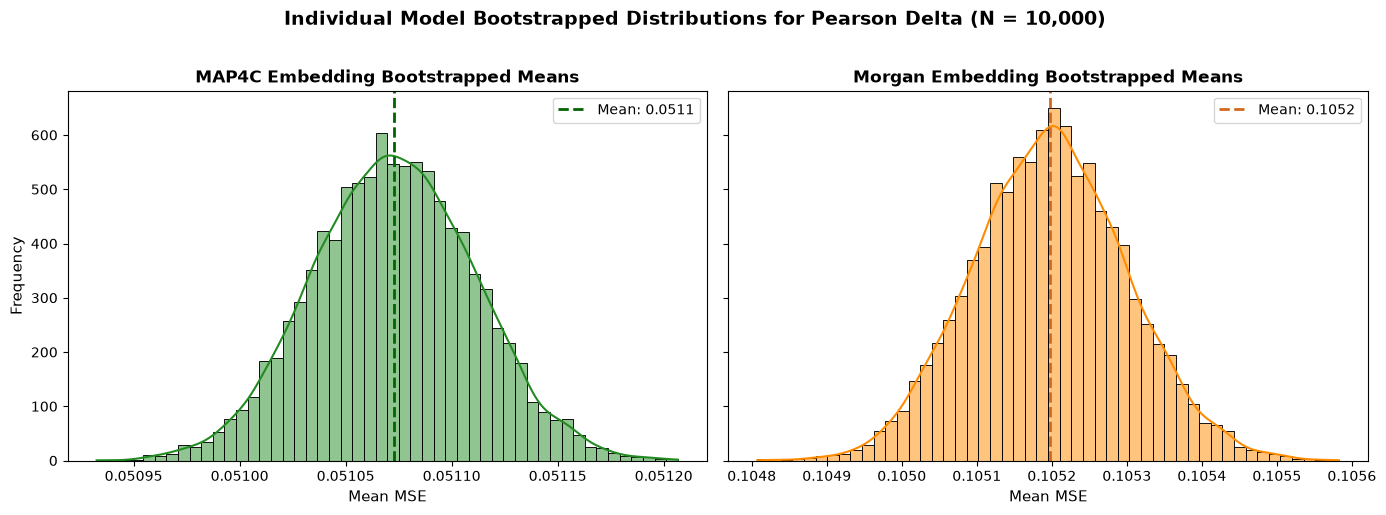

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

sns.histplot(results3['fp_means'], kde=True, color='forestgreen', bins=50, ax=axes[0])
mean_fp = results3['fp_means'].mean()
axes[0].axvline(mean_fp, color='darkgreen', linestyle='--', linewidth=2, label=f"Mean: {mean_fp:.4f}")
axes[0].set_title("MAP4C Embedding Bootstrapped Means", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Mean MSE", fontsize=11)
axes[0].set_ylabel("Frequency", fontsize=11)
axes[0].legend()

sns.histplot(results3['smiles_means'], kde=True, color='darkorange', bins=50, ax=axes[1])
mean_smiles = results3['smiles_means'].mean()
axes[1].axvline(mean_smiles, color='chocolate', linestyle='--', linewidth=2, label=f"Mean: {mean_smiles:.4f}")
axes[1].set_title("Morgan Embedding Bootstrapped Means", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Mean MSE", fontsize=11)
axes[1].legend()

plt.suptitle(f"Individual Model Bootstrapped Distributions for Pearson Delta (N = {num_bootstraps:,})", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

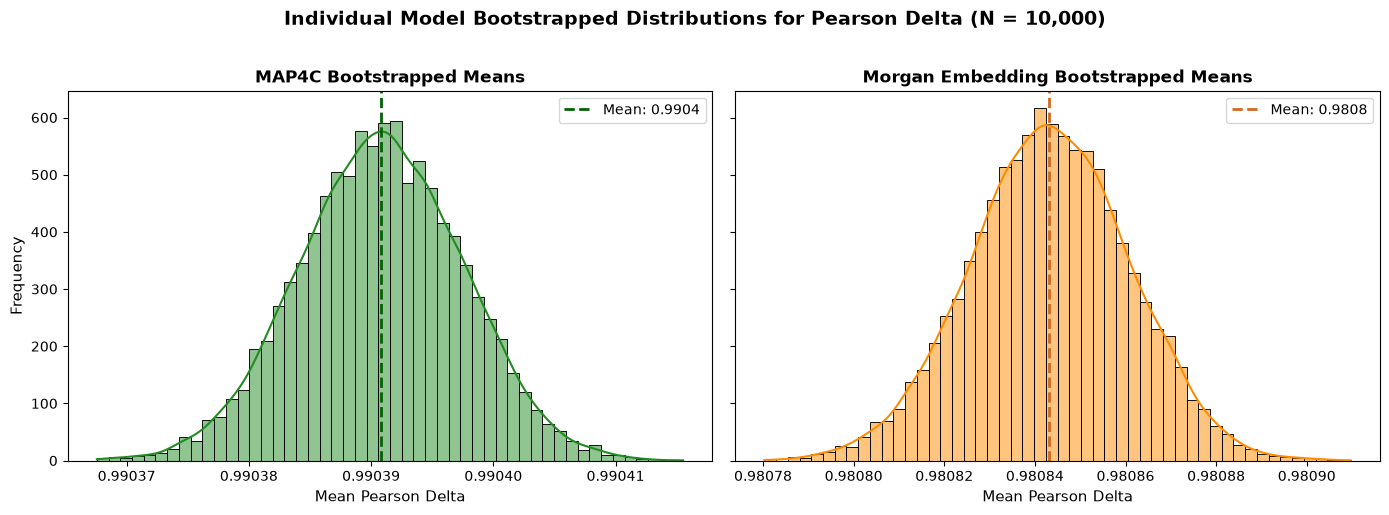

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

sns.histplot(results4['fp_means'], kde=True, color='forestgreen', bins=50, ax=axes[0])
mean_fp = results4['fp_means'].mean()
axes[0].axvline(mean_fp, color='darkgreen', linestyle='--', linewidth=2, label=f"Mean: {mean_fp:.4f}")
axes[0].set_title("MAP4C Bootstrapped Means", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Mean Pearson Delta", fontsize=11)
axes[0].set_ylabel("Frequency", fontsize=11)
axes[0].legend()

sns.histplot(results4['smiles_means'], kde=True, color='darkorange', bins=50, ax=axes[1])
mean_smiles = results4['smiles_means'].mean()
axes[1].axvline(mean_smiles, color='chocolate', linestyle='--', linewidth=2, label=f"Mean: {mean_smiles:.4f}")
axes[1].set_title("Morgan Embedding Bootstrapped Means", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Mean Pearson Delta", fontsize=11)
axes[1].legend()

plt.suptitle(f"Individual Model Bootstrapped Distributions for Pearson Delta (N = {num_bootstraps:,})", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

##### Relative Delta MSE

In [110]:
# Experiment 1
baseline_mse = np.mean(smiles_agg_mse)
new_mse = np.mean(fp_agg_mse)
delta_MSE = (new_mse - baseline_mse) / baseline_mse

In [113]:
round(delta_MSE, 4)

np.float64(-0.5254)

In [114]:
# Experiment 2

baseline_mse2 = np.mean(smiles_agg_mse2)
new_mse2 = np.mean(fp_agg_mse2)
delta_MSE2 = (new_mse2 - baseline_mse2) / baseline_mse2

In [115]:
round(delta_MSE2, 4)

np.float64(-0.5145)